In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset

In [4]:
weather_df = pd.read_csv("global_weather_100_cities_2014_2024.csv", parse_dates=['date'])
weather_df

,date,avg_temperature_c,avg_humidity_pct,rainfall_mm,max_wind_speed_kmh,city
0,2014-01-01,22.0,77,0.0,23.8,Cape Town
1,2014-01-01,11.2,72,0.0,9.2,Casablanca
2,2014-01-01,12.2,80,0.0,13.8,Delhi
3,2014-01-01,18.8,59,0.0,13.0,Johannesburg
4,2014-01-01,26.7,86,1.8,15.1,Lagos
...,...,...,...,...,...,...
48211,2024-12-31,27.3,59,0.0,12.4,Mumbai
48212,2024-12-31,20.1,67,0.6,16.1,Nairobi
48213,2024-12-31,6.3,74,0.0,12.9,New York
48214,2024-12-31,3.9,90,0.0,15.8,Paris


# Data Exploratory

In [5]:
weather_df.isna().sum()

date                  0
avg_temperature_c     0
avg_humidity_pct      0
rainfall_mm           0
max_wind_speed_kmh    0
city                  0
dtype: int64

# Data cleaning

In [6]:
weather_df.rename(columns={"avg_temperature_c": "temp"}, inplace=True)
weather_df.rename(columns={"max_wind_speed_kmh": "wind"}, inplace=True)
weather_df.rename(columns={"rainfall_mm": "rainfall"}, inplace=True)
weather_df.rename(columns={"avg_humidity_pct": "humidity"}, inplace=True)


# Extracting features

In [7]:
mons = weather_df["date"].dt.month
years = weather_df["date"].dt.year

# add features
weather_df["Month"] = mons
weather_df["Year"] = years


# Creating
# Dec, Jan, Feb -> Winter
# March, April, May -> Spring
# June, July, August -> Summer
# Sep, Oct, Nov -> Autumn

def get_seasons(months):
    if months in [12, 1, 2]:
        return  "Winter"
    elif months in [3, 4, 5]:
        return "Spring"
    elif months in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

# Add Season column
weather_df['Season'] = weather_df.Month.apply(get_seasons)

# Analyze the Data

In [8]:
avg_temp_per_month = weather_df.groupby('Month').temp.mean()
total_rainfall = weather_df.groupby('Month').rainfall.sum()
avg_temp_per_season = weather_df.groupby('Season').temp.mean()
months = weather_df["date"].dt.month.unique()
seasons = weather_df["Season"].unique()
max_temp = weather_df.temp.max()
min_temp = weather_df.temp.min()

# view dataset after clearning

In [9]:
weather_df

,date,temp,humidity,rainfall,wind,city,Month,Year,Season
0,2014-01-01,22.0,77,0.0,23.8,Cape Town,1,2014,Winter
1,2014-01-01,11.2,72,0.0,9.2,Casablanca,1,2014,Winter
2,2014-01-01,12.2,80,0.0,13.8,Delhi,1,2014,Winter
3,2014-01-01,18.8,59,0.0,13.0,Johannesburg,1,2014,Winter
4,2014-01-01,26.7,86,1.8,15.1,Lagos,1,2014,Winter
...,...,...,...,...,...,...,...,...,...
48211,2024-12-31,27.3,59,0.0,12.4,Mumbai,12,2024,Winter
48212,2024-12-31,20.1,67,0.6,16.1,Nairobi,12,2024,Winter
48213,2024-12-31,6.3,74,0.0,12.9,New York,12,2024,Winter
48214,2024-12-31,3.9,90,0.0,15.8,Paris,12,2024,Winter


# Visualization

✓ Image saved to: weather.png


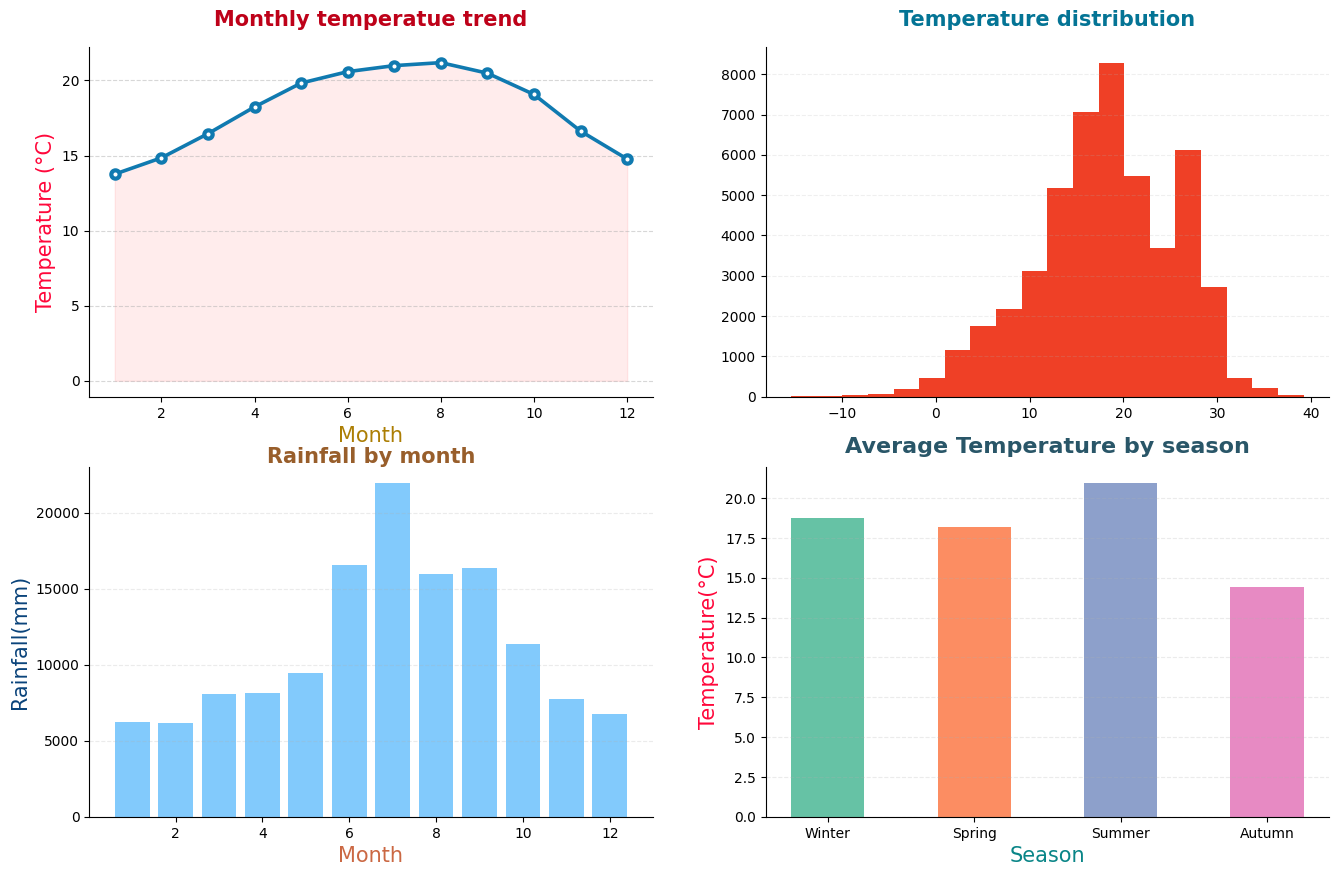

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(16, 10))

ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

# Line chart(Monthly temperature trend)
# plot
ax1.plot(
    months, avg_temp_per_month,
    color="#107ab0", linewidth=2.6,
    marker="o", markersize=6, markerfacecolor='w', markeredgewidth=3.0)

# style
ax1.fill_between(months, avg_temp_per_month, alpha=0.1, color="#ff474c")
ax1.set_title("Monthly temperatue trend", color='#be0119', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Month", fontsize=15, color="#ac7e04")
ax1.set_ylabel("Temperature (°C)", fontsize=15, color="#ff073a")
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", linestyle="--", alpha=0.5)


# Histogram(Temperature distribution) 
ax2.hist(weather_df["temp"], bins=20, color="#ef4026")

# style
ax2.set_title("Temperature distribution", color="#047495", fontsize=15, fontweight='bold', pad=15)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", linestyle="--", alpha=0.2)


# Bar chart(Rainfall by month)
ax3.bar(months, total_rainfall, color="#82cafc")

# style
ax3.set_title("Rainfall by month", color="#985e2b", fontsize=15, fontweight='bold', pad=0.11)
ax3.spines[["top", "right"]].set_visible(False)
ax3.set_xlabel("Month", color="#cb6843", fontsize=15)
ax3.set_ylabel("Rainfall(mm)", color="#0a437a", fontsize=15)
ax3.grid(axis="y", linestyle="--", alpha=0.25)


# Bar chart(Average Temperature by season)
colors = plt.cm.Set2.colors # auto generate distinct colors
ax4.bar(seasons, avg_temp_per_season, width=0.5, color=colors[:len(seasons)])
ax4.set_title("Average Temperature by season", color="#295668", fontsize=16, fontweight="bold", pad=10)
ax4.set_xlabel("Season", color="#098587", fontsize=15)
ax4.set_ylabel("Temperature(°C)", color="#ff073a", fontsize=15)
ax4.grid(axis="y", linestyle="--", alpha=0.25)
ax4.spines[["top", "right"]].set_visible(False)


# Image location
FILE = "weather.png"
IMG_FILE = FILE

# save image
plt.savefig(IMG_FILE, dpi=150, bbox_inches="tight")
print(f"✓ Image saved to: {IMG_FILE}")

plt.show()